# Pertemuan 13 — Deep Learning & NLP: Klasifikasi Non-Linear & Analisis Sentimen

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


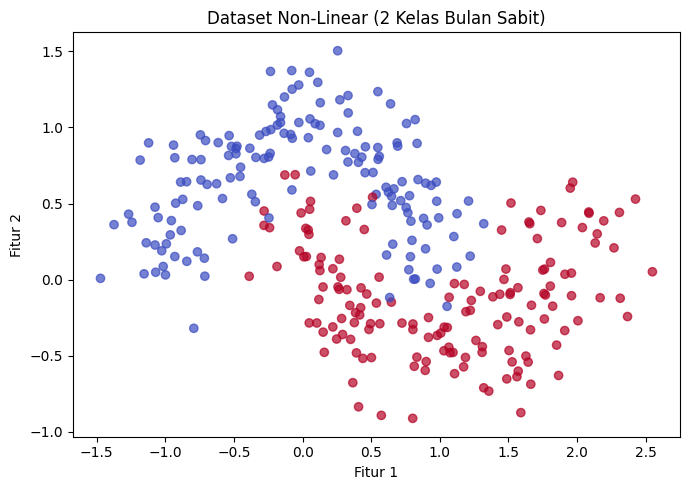

Shape dataset: (300, 2)
Distribusi kelas: {np.int64(0): np.int64(150), np.int64(1): np.int64(150)}


In [1]:
# Langkah 1: Generate & Eksplorasi Dataset Non-Linear
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.tight_layout()
plt.show()

print('Shape dataset:', X.shape)
print('Distribusi kelas:', dict(zip(*[list(v) for v in __import__('numpy').unique(y, return_counts=True)])))

### Observasi Dataset Non-Linear

Kedua kelas saling melengkung dan bertautan membentuk pola bulan sabit. Pola seperti ini tidak mungkin dipisahkan dengan satu garis lurus — inilah mengapa kita membutuhkan neural network yang mampu mempelajari batas keputusan non-linear.


In [2]:
# Langkah 2: Bangun & Latih Neural Network Sederhana
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr,
                    epochs=30,
                    validation_split=0.2,
                    verbose=0)
print('Training selesai!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai!


Akurasi pada data uji: 0.917


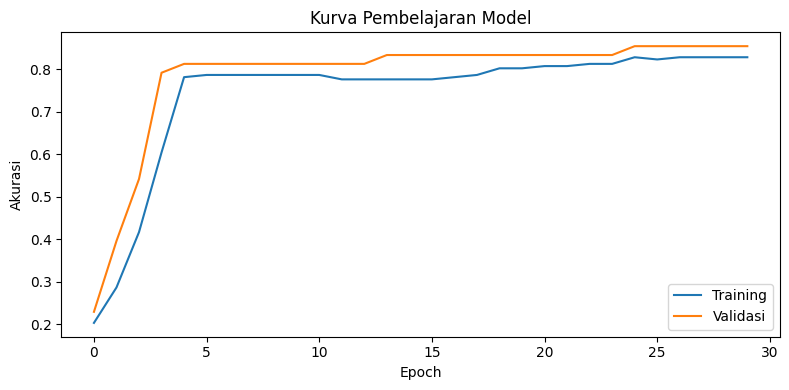

In [3]:
# Langkah 3: Evaluasi & Visualisasi Kurva Belajar
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'],     label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Pembelajaran Model')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretasi Kurva Belajar

Kurva akurasi training dan validasi yang saling mendekat dan stabil menunjukkan model belajar dengan baik tanpa overfitting. Jika kurva validasi justru turun sementara training terus naik, itu sinyal overfitting dan perlu ditangani dengan dropout atau regularisasi.


In [4]:
# Langkah 4: Siapkan Dataset Ulasan Produk (40 ulasan sintetis)
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Produk original, pengiriman aman',
    'Mengecewakan, bahan tidak seperti foto',
    'Sangat memuaskan, penjual ramah',
    'Barang tidak sesuai pesanan, minta refund',
    'Kualitas premium, worth it banget',
    'Lambat sekali pengirimannya, kecewa',
    'Produk bagus dan tahan lama',
    'Tidak rekomen, mudah rusak',
    'Penjual responsif, barang sesuai foto',
    'Warna berbeda dari gambar, kecewa',
    'Mantap, sudah order berkali-kali',
    'Kualitas sangat buruk, tidak worth it',
    'Pengiriman cepat, packaging rapi',
    'Barang cacat, tidak ada respon penjual',
    'Suka banget produknya, sesuai ekspektasi',
    'Tidak sesuai ukuran, mau retur',
    'Produk terbaik yang pernah saya beli',
    'Penipu, barang tidak dikirim',
    'Sangat recommended untuk semua orang',
    'Bahan tipis, tidak sesuai harga',
    'Barang sampai dalam kondisi baik',
    'Kecewa berat, produk palsu',
    'Senang banget, sesuai deskripsi',
    'Jahitan jelek, langsung rusak',
    'Toko terpercaya, produk berkualitas',
    'Sangat buruk, tidak mau beli lagi',
    'Harga terjangkau, kualitas memuaskan',
    'Barang tidak lengkap, minus bintang',
    'Pengiriman super cepat, aman',
    'Produk mudah rusak, tidak tahan lama',
    'Luar biasa, melebihi ekspektasi',
    'Bau menyengat, tidak nyaman dipakai',
    'Pelayanan ramah, barang oke',
    'Sampah, buang uang saja'
]

label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]  # 1 = positif, 0 = negatif

print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Positif: {label.count(1)}, Negatif: {label.count(0)}')
print('\nContoh ulasan positif:', ulasan[0])
print('Contoh ulasan negatif:', ulasan[1])

Jumlah ulasan: 40
Positif: 20, Negatif: 20

Contoh ulasan positif: Barangnya bagus banget, pengiriman cepat
Contoh ulasan negatif: Kualitas jelek, tidak sesuai deskripsi


In [5]:
# Langkah 5: Ubah Teks Menjadi TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf   = TfidfVectorizer()
X_text  = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 kata pertama dalam vocabulary:')
print(tfidf.get_feature_names_out()[:10])
print(f'\nShape matriks TF-IDF: {X_text.shape}')

Jumlah kata unik: 107
10 kata pertama dalam vocabulary:
['ada' 'akan' 'aman' 'bagus' 'bahan' 'baik' 'banget' 'barang' 'barangnya'
 'bau']

Shape matriks TF-IDF: (40, 107)


Akurasi model sentimen : 0.750
Precision              : 0.750
Recall                 : 0.750
F1-Score               : 0.750


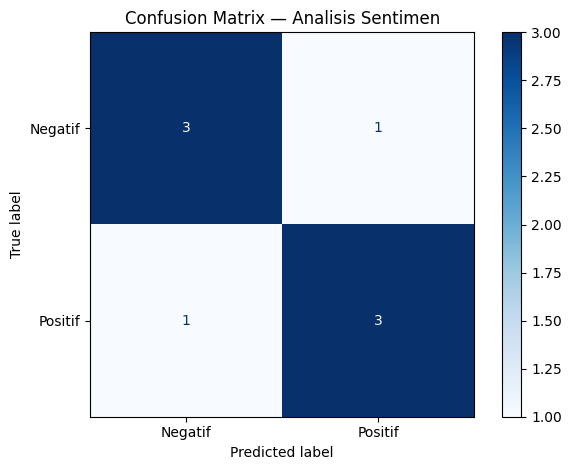

In [6]:
# Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

yt_pred = model_sentimen.predict(Xt_te)
akurasi = accuracy_score(yt_te, yt_pred)

print(f'Akurasi model sentimen : {akurasi:.3f}')
print(f'Precision              : {precision_score(yt_te, yt_pred, zero_division=0):.3f}')
print(f'Recall                 : {recall_score(yt_te, yt_pred, zero_division=0):.3f}')
print(f'F1-Score               : {f1_score(yt_te, yt_pred, zero_division=0):.3f}')

# Confusion Matrix
cm = confusion_matrix(yt_te, yt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negatif', 'Positif'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Analisis Sentimen')
plt.tight_layout()
plt.show()

In [7]:
# Uji dengan kalimat baru
kalimat_baru = [
    'Pelayanan sangat memuaskan dan ramah',
    'Barang rusak dan tidak sesuai foto',
    'Produk berkualitas, harga worth it'
]

for kalimat in kalimat_baru:
    pred = model_sentimen.predict(tfidf.transform([kalimat]))
    hasil = 'Positif' if pred[0] == 1 else 'Negatif'
    print(f'"{kalimat}" → {hasil}')

"Pelayanan sangat memuaskan dan ramah" → Positif
"Barang rusak dan tidak sesuai foto" → Negatif
"Produk berkualitas, harga worth it" → Positif


## Kesimpulan — Pertemuan 13: Deep Learning & NLP

Pertemuan ini memperkenalkan dua hal yang cukup berbeda dari materi sebelumnya. Bagian pertama tentang neural network membuka pemahaman saya tentang kenapa model linear tidak selalu cukup — dataset berbentuk bulan sabit yang sederhana saja sudah tidak bisa dipisahkan dengan garis lurus, dan neural network dengan activation function ReLU bisa menanganinya dengan baik.

Bagian TF-IDF cukup menarik karena ini pertama kalinya saya mengolah data teks menjadi angka. Ide dasarnya sederhana: kata yang sering muncul di satu dokumen tapi jarang di dokumen lain mendapat bobot lebih tinggi. Dengan representasi ini, Logistic Regression biasa sudah bisa mengklasifikasikan sentimen ulasan dengan cukup baik.

Keterbatasan yang saya sadari: dataset ulasan yang digunakan masih sintetis dan sangat kecil (40 ulasan), sehingga performa model di data nyata belum tentu sama. TF-IDF juga tidak mempertimbangkan urutan kata — 'tidak bagus' dan 'bagus tidak' dianggap sama, padahal maknanya berbeda. Ini yang membuat model bahasa modern seperti BERT jauh lebih unggul untuk NLP.
